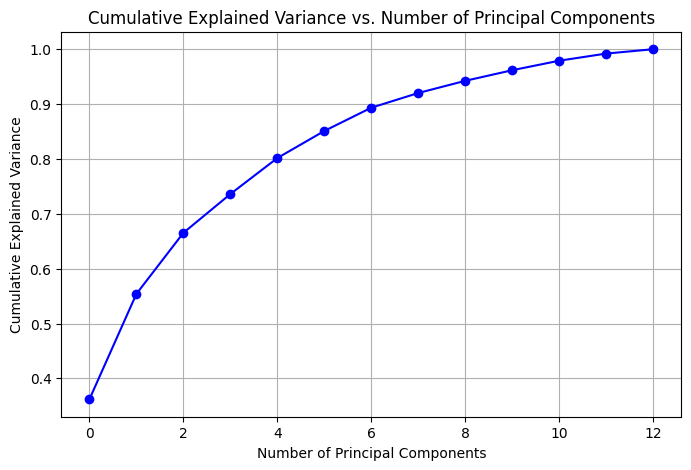

Original dataset shape: (178, 13)
Reduced dataset shape (95% variance retained): (178, 10)


In [1]:
# Step 1: Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

# Step 2: Load the Wine dataset
wine_data = load_wine()
X = wine_data.data  # Features
y = wine_data.target  # Target labels

# Step 3: Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Step 5: Explained variance ratio (how much variance is explained by each principal component)
explained_variance = pca.explained_variance_ratio_

# Plotting the cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(explained_variance), marker='o', color='b')
plt.title('Cumulative Explained Variance vs. Number of Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Step 6: Reduce dimensionality to retain most of the variance
# Let's say we want to retain 95% of the variance
n_components = np.argmax(np.cumsum(explained_variance) >= 0.95) + 1
pca = PCA(n_components=n_components)
X_pca_95 = pca.fit_transform(X_scaled)

# The new shape of the dataset after dimensionality reduction
print(f"Original dataset shape: {X.shape}")
print(f"Reduced dataset shape (95% variance retained): {X_pca_95.shape}")
